# Tutorial to GW data
Using GWUtils, we are able to fetch public GW databases and retrieve their characteristics and sky map

## 1) GW event 

### Load data

Events data are mainly stored in two online databases : GWTC, containing human-validated transients ; and GraceDB, storing data related to all alerts sent by the LVK network (started around O3)

GWTC identifies events via a tag starting with GW, e.g. "GW170817"
GraceDB stores events under a 'Superevent' structure, owning several alerts regarding the same event. Those are identified with a superevent id, e.g. "S250830bp".

/home/llebrun/Desktop/GWUtils/.GWvenv/lib/python3.12/site-packages/ligo/skymap/io/events/ligolw.py:26: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/home/llebrun/Desktop/GWUtils/.GWvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'$defs': {'CBCClassification': {'properties': {'astro': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Astro'}, 'Terrestrial': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Terrestrial'}, 'BBH': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Bbh'}, 'BNS': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Bns'}, 'NSBH': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': None, 'title': 'Nsbh'}, 'source_pipeline': {'anyOf': [{'type': 'string'}, {'type': 'null'}], 'default': None, 'title': 'Source Pipeline'}}, 'title': 'CBCClassification', 'type': 'object'}, 'Detector': {'enum': ['H1', 'L1', 'V1', 'K1'], 'title': 'Detector', 'type': 'string'}, 'UncertainQuantity': {'description': 'A measured value with asymmetric uncertainties.', 'properties': {'value': {'title': 'Value', 'type': 'number'}, 'lower': {'anyOf': [{'type': 'number'}, {'type': 'null'}], 'default': Non

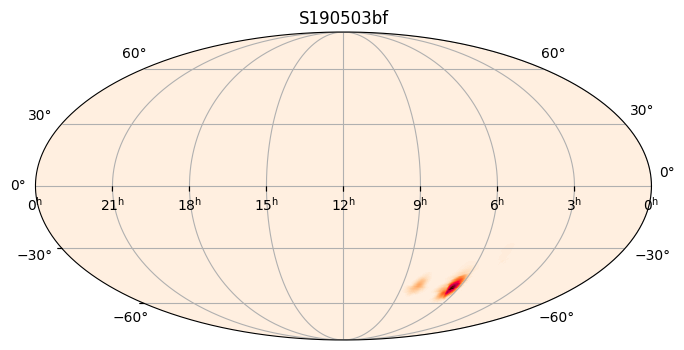

(<Figure size 900x400 with 1 Axes>,
 <AstroHoursMollweideAxes: title={'center': 'S190503bf'}>)

In [1]:
from GWUtils.models_gw import GWEvent

name = 'S190503bf'
gw170817 = GWEvent(name, offline=False)  # Turn this online if no cache yet ; you may need ligo token to access non-public events

# Demonstration 
print(gw170817.model_json_schema())
gw170817.plot_event()

In [2]:
gw170817.to_dict()

{'superevent_id': 'S190503bf',
 'gw_id': None,
 'catalog': 'IAS-O3a',
 'created': datetime.datetime(2019, 5, 3, 18, 54, 26, tzinfo=datetime.timezone.utc),
 't_start': datetime.datetime(2019, 5, 3, 18, 54, 3, 288574, tzinfo=datetime.timezone.utc),
 't_end': datetime.datetime(2019, 5, 3, 18, 54, 5, 422852, tzinfo=datetime.timezone.utc),
 't_0': datetime.datetime(2019, 5, 3, 18, 54, 4, 412598, tzinfo=datetime.timezone.utc),
 'gps': 1240944862.3,
 'detectors': 'H1,L1,V1',
 'group': 'CBC',
 'preferred_event': 'G331315',
 'network_snr': 11.9,
 'far': 0.001,
 'p_astro': 1.0,
 'skymap_ready': True,
 'pastro_ready': True,
 'bbh': 0.9628101949990394,
 'bns': 0.0,
 'nsbh': 0.004733723851664969,
 'terrestrial': 0.00012483474899949398,
 'mass_1': 42.0,
 'mass_1_lower': -7.0,
 'mass_1_upper': 78.0,
 'mass_2': 31.0,
 'mass_2_lower': -16.0,
 'mass_2_upper': 9.0,
 'chirp_mass': 31.0,
 'chirp_mass_lower': -7.0,
 'chirp_mass_upper': 20.0,
 'total_mass': 73.0,
 'total_mass_lower': -12.0,
 'total_mass_uppe

## Compute regions of interest (MOCs)

/home/llebrun/Desktop/GWUtils/.GWvenv/lib/python3.12/site-packages/astropy_healpix/core.py:668: RuntimeWarning: invalid value encountered in neighbours_nested
  return np.stack(func(healpix_index, nside))


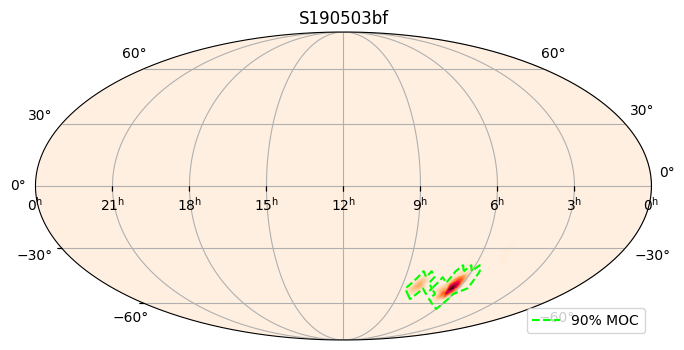

(<Figure size 900x400 with 1 Axes>,
 <AstroHoursMollweideAxes: title={'center': 'S190503bf'}>)

In [3]:
gw170817.plot_event(n_vertices=50)

### Extract MOC 

In [4]:
moc = gw170817.get_roi(n_vertices=50, format='moc')
moc_dict = gw170817.get_roi(n_vertices=50, format='dict')

/home/llebrun/Desktop/GWUtils/.GWvenv/lib/python3.12/site-packages/astropy_healpix/core.py:668: RuntimeWarning: invalid value encountered in neighbours_nested
  return np.stack(func(healpix_index, nside))


In [5]:
type(moc)

mocpy.moc.moc.MOC

In [6]:
moc_dict

{'superevent_id': 'S190503bf',
 'percentile': 90,
 'order': 4,
 'area_deg2': 362.5748547312241,
 'n_vertices': 36,
 'contours': [[(95.625, -41.810314895778596),
   (98.4375, -38.68218745348944),
   (101.25, -41.810314895778596),
   (102.0, -44.99388015045712),
   (102.85714285714286, -48.14120779436028),
   (108.0, -44.99388015045712),
   (109.28571428571429, -48.141207794360284),
   (110.76923076923077, -51.255806948804874),
   (105.0, -54.34091230386123),
   (106.36363636363636, -57.39952353962293),
   (99.0, -60.434438844952275),
   (90.0, -63.44828368030107),
   (90.0, -60.434438844952275),
   (90.0, -57.39952353962295),
   (90.0, -54.34091230386123),
   (83.07692307692308, -51.25580694880489),
   (83.57142857142858, -48.141207794360284),
   (84.0, -44.99388015045712),
   (84.375, -41.810314895778596),
   (87.1875, -38.68218745348944),
   (90.0, -41.810314895778596),
   (92.8125, -38.68218745348944)],
  [(127.50000000000001, -54.34091230386123),
   (122.72727272727273, -57.39952353

In [7]:
moc

3/610 612 616 
4/2128-2129 2132-2133 2362-2363 2434-2435 2439 2444 2446 2456 2472-2474 

In [ ]:
from pathlib import Path
savePath = Path("/path/to/your/installation/of/LSST-GW/src/output") # TODO : adapt this path to your installation
moc.save(savePath / f"{name}_moc.fits", overwrite=True)

Now you can use the saved file to create a watchmap on a Rubin broker. 

## 2) Rubin past data (/!\ exercise)

At this point, two actions can be taken : 
- Configure a Rubin broker to acquire live alerts related to the localisation region of the event of our choice.
- Browse a broker alert database to see past (in particular, recent) alerts within this zone.

Live alerts configuration are mainly done on the broker website and are the topic of another tutorial under `Lasair tutorial.pdf`.
For now, let us look at what Rubin has already acquired for us.

If you have configured your watchmap and filter before, you now know how lasair works. Use the broker to fetch past alerts in the MOC. The watchmap will not help at first since it does not retrieve past alerts automatically. Instead, you can e.g. configure a filter manually that queries the watchmap region using the SQL wizard on the Lasair website. 